In [2]:
import pandas as pd
df = pd.read_csv('earthquake.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())

                       time  latitude  longitude    depth  mag magType    nst  \
0  2025-12-08T23:59:06.930Z   40.8430   142.7043   46.371  5.6      mb   76.0   
1  2025-12-08T22:07:17.220Z   41.0385   142.8600   35.000  5.0      mb   55.0   
2  2025-12-08T21:52:41.302Z   41.0034   143.1637   19.000  6.6     mww  129.0   
3  2025-12-08T20:39:39.276Z   -7.1830   129.3461  144.597  4.8      mb   23.0   
4  2025-12-08T20:31:36.728Z   11.1530   138.5774   10.000  5.0      mb   41.0   

     gap   dmin   rms  ...                   updated  \
0   95.0  1.219  0.77  ...  2025-12-09T03:10:14.627Z   
1  101.0  1.001  0.82  ...  2025-12-09T06:04:24.199Z   
2   29.0  1.011  0.55  ...  2025-12-09T05:10:05.044Z   
3   66.0  2.701  0.82  ...  2025-12-08T20:50:42.040Z   
4   49.0  5.543  0.82  ...  2025-12-08T20:57:05.040Z   

                                 place        type horizontalError depthError  \
0             107 km NE of Kuji, Japan  earthquake            6.54      6.556   
1            1

In [11]:
import numpy as np
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df['updated'] = pd.to_datetime(df['updated'], errors='coerce')

numeric_cols = ['latitude','longitude','depth','mag','nst','gap','dmin','rms','horizontalError'
                ,'depthError','magError','magNst']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.drop_duplicates(inplace=True)

df['nst'] = df['nst'].fillna(df['nst'].median())
df['gap'] = df['gap'].fillna(df['gap'].median())
df['dmin'] = df['dmin'].fillna(df['dmin'].median())
df['horizontalError'] = df['horizontalError'].fillna(df['horizontalError'].median())
df['magError'] = df['magError'].fillna(df['magError'].median())
df['magNst'] = df['magNst'].fillna(df['magNst'].median())


cat_cols = ['magType','net','id','place','type','status','locationSource','magSource']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


df = df[df['mag'] > 0]
df = df[df['depth'] >= 0]
df = df[df['latitude'].between(-90,90)]
df = df[df['longitude'].between(-180,180)]

df_cleaned = df.copy()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15586 entries, 0 to 15585
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             15586 non-null  datetime64[ns, UTC]
 1   latitude         15586 non-null  float64            
 2   longitude        15586 non-null  float64            
 3   depth            15586 non-null  float64            
 4   mag              15586 non-null  float64            
 5   magType          15586 non-null  object             
 6   nst              15586 non-null  float64            
 7   gap              15586 non-null  float64            
 8   dmin             15586 non-null  float64            
 9   rms              15586 non-null  float64            
 10  net              15586 non-null  object             
 11  id               15586 non-null  object             
 12  updated          15586 non-null  datetime64[ns, UTC]
 13  place           

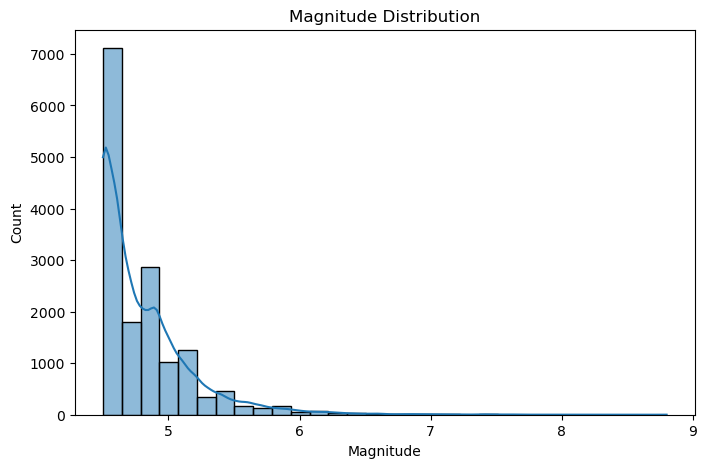

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['mag'], kde=True, bins=30)
plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()

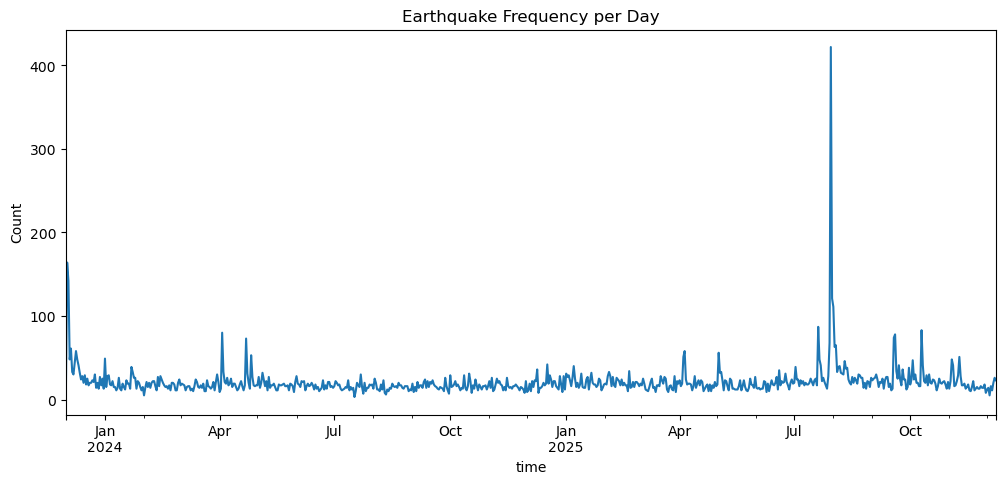

In [13]:
plt.figure(figsize=(12,5))
df.resample('D', on='time').size().plot()
plt.title("Earthquake Frequency per Day")
plt.ylabel("Count")
plt.show()

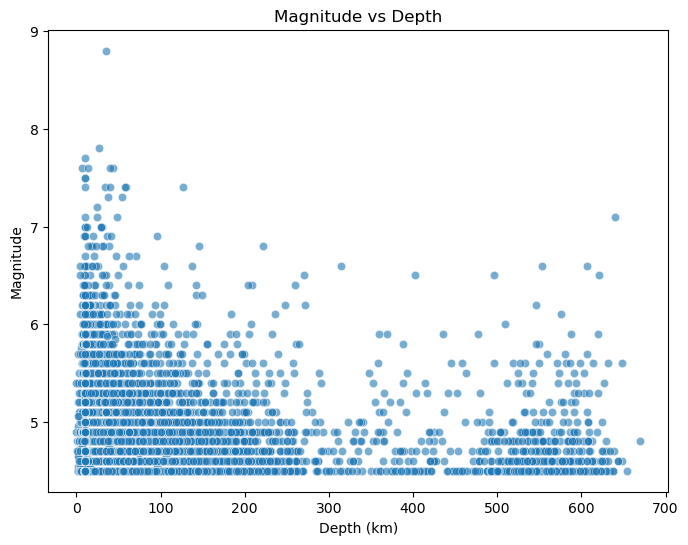

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='depth', y='mag', alpha=0.6)
plt.title("Magnitude vs Depth")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()

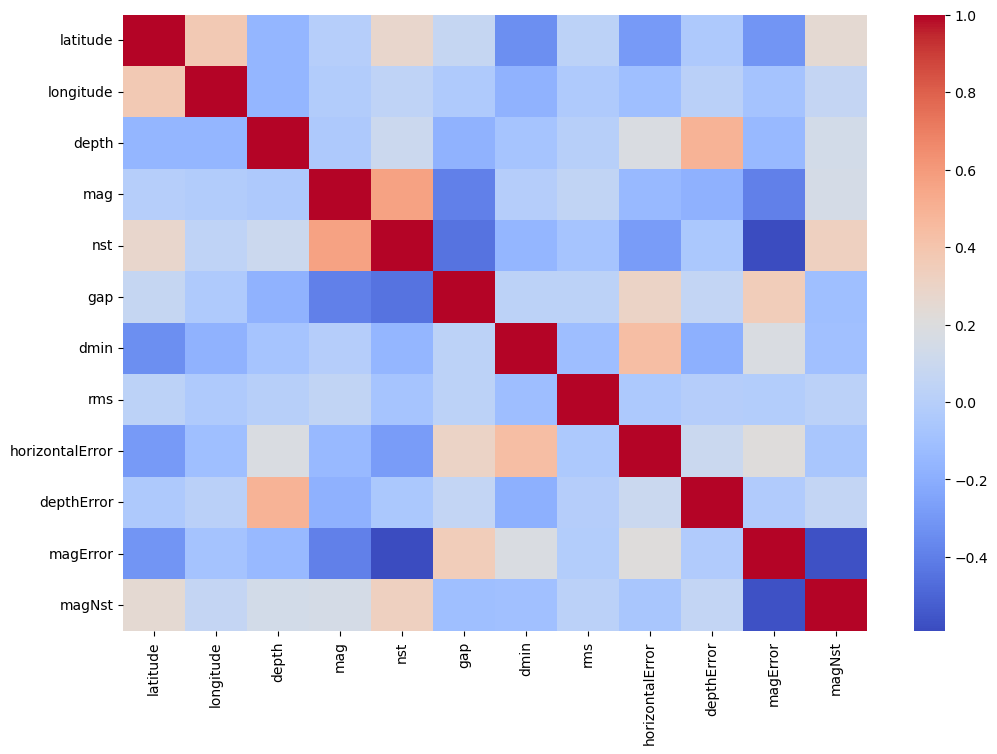

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [16]:
print(df.dtypes)

time               datetime64[ns, UTC]
latitude                       float64
longitude                      float64
depth                          float64
mag                            float64
magType                         object
nst                            float64
gap                            float64
dmin                           float64
rms                            float64
net                             object
id                              object
updated            datetime64[ns, UTC]
place                           object
type                            object
horizontalError                float64
depthError                     float64
magError                       float64
magNst                         float64
status                          object
locationSource                  object
magSource                       object
dtype: object
